# The Fourth Circle: Neural Networks, Part Three 
## Recurrent Neural Networks III: Gated Recurrent Unit

<br/>
Jiří Fejlek

2026-03-17
<br/>

## Table of Contents

- [Gated Recurrent Unit](#gru)
    - [Implementation](#impl)
    - [Training LSTM on The Time Machine](#train)
- [References](#references)

Gated Recurrent Unit (GRU) [[1](#1)] is a simplified version of the Long Short-Term Memory (LSTM) memory cell architecture [[2](#2)] introduced in 2014. It offers a more streamlined, easier-to-compute memory unit that retains the advantages of LSTMs. 

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader
import torch.nn.functional as F

import re
import collections

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 3050 Laptop GPU'

In [3]:
class Vocabulary: 

    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        
        # Flatten the list of tokens
        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        
        # Count token frequencies
        counter = collections.Counter(tokens)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse = True)

        # The list of unique tokens, we ignore tokens with frequency lower than min_freq
        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [token for token, freq in self.token_freqs if freq >= min_freq]))) 
        # convert tokens to indices
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
     
    def __len__(self):
        return len(self.idx_to_token)
    
    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk) # return unknown token if not in the vocabulary
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        if hasattr(indices, '__len__') and len(indices) > 1:
            return [self.idx_to_token[int(index)] for index in indices]
        return self.idx_to_token[indices]
    
    @property
    def unk(self): # index for the unknown token
        return self.token_to_idx['<unk>']

In [4]:
class TimeMachine: 
    
    def _read(self): # read the text 
        return open('C:/Users/elini/Desktop/nine circles 2/timemachine.txt').read()
        
    def _preprocess(self, text): # replace special characters with ' ', convert upper cases to lower case
        return re.sub('[^A-Za-z]+', ' ', open('C:/Users\elini/Desktop/nine circles 2/timemachine.txt').read()).lower()

    def _tokenize(self, text): # convert text to a list of words
         return text.split()
        
    def _build(self, raw_text, vocab=None): # built vocabulary
        tokens = self._tokenize(self._preprocess(raw_text))
        if vocab is None: 
            vocab = Vocabulary(tokens)
        corpus = [vocab[token] for token in tokens]
        return corpus, vocab
        
    ################################
    
    def __init__(self, batch_size, num_steps, num_train = 10000, num_test = 5000):  

        self.batch_size = batch_size
        self.num_train = num_train
        self.num_test = num_test
        
        corpus, self.vocab = self._build(self._read()) # build vocabulary
        array = torch.tensor([corpus[i:i+num_steps+1] for i in range(len(corpus)-num_steps)]) # extract sequences from the text
        self.X, self.Y = array[:,:-1], array[:,1:] # Y is shifted by one index

    
    # dataloader
    def get_dataloader(self, train): 
        # sequences till num_train are from the train set, the latter are from the test set 
        idx = slice(0, self.num_train) if train else slice(self.num_train, self.num_train + self.num_test) 
        return self.get_tensorloader([self.X, self.Y], train, idx)
        
    def train_dataloader(self):
        return self.get_dataloader(train=True)
        
    def test_dataloader(self):
        return self.get_dataloader(train=False)
        
    # we will simply use the dataloader from torch
    def get_tensorloader(self, tensors, train, indices=slice(0, None)):
        tensors = tuple(a[indices] for a in tensors) # get train/test sequences based on idx
        dataset = torch.utils.data.TensorDataset(*tensors) 
        return torch.utils.data.DataLoader(dataset, self.batch_size, shuffle=train)    

In [5]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler, max_norm):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits, state = model(X) # forward pass
        
        loss = loss_fn(pred_logits.permute(1, 2, 0), y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = max_norm) # gradient clipping
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
           
    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            state = None
            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test, state = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test.permute(1, 2, 0), y_test)*len(X_test)
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0]

In [6]:
def predict(model, prefix, num_preds, vocab, device):
    prefix = prefix.split()
    prefix = torch.tensor([vocab.__getitem__(prefix)]).to(cuda_device)
    h_state = None

    for i in range(num_preds):
        Y_pred, h_state = model(prefix, h_state)
        Y_pred = Y_pred[-1,::]
        prefix = torch.cat((prefix[0],Y_pred.argmax()[None]),0)[None,:]

    predicted_text = vocab.to_tokens(prefix[0].tolist())
    delimeter = ' '
        
    return delimeter.join(predicted_text)

## Gated Recurrent Unit <a class="anchor" id="gru"></a>

The architecture of the GRU is as follows [[3](#3)].

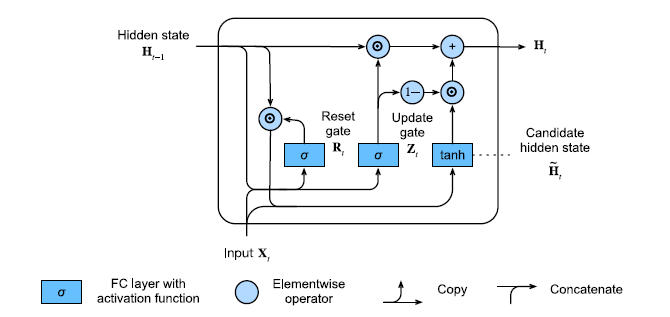

Unlike an LSTM memory cell, a GRU unit consists of only two gates: a reset gate and an update gate [[3](#3)]:
$$ r_t = \sigma  (W_{xr}x_t + W_{hr}h_{t-1} + b_r), $$
$$ z_t = \sigma  (W_{xz}x_t + W_{hz}h_{t-1} + b_z), $$
where $W_{xr}, W_{xz}$ are weight matrices and $b_r, b_z$ are biases. The hidden state of the RNN is updated as follows
$$ h_t = z_t \odot h_{t-1} + (1-z_t) \odot \tilde{h}_t,$$
where $\odot$ is the Hadamard (elementwise) product, and where $\tilde{h}_t$ is a *candidate hidden state*
$$ \tilde{h}_t = \text{tanh } \left(  W_{xh} x_t + W_{hh}(r_t \odot h_{t-1}) + b_h \right)$$
where  $W_{xh}, W_{hh}$ are weight matrices and $b_h$ is a bias term. 

From these equations, we observe that the update gate determines whether we update the hidden state or retain the existing one. On the other hand, the reset gate can "reset" the memorized hidden state and create a new candidate purely from the current input. 

### Implementation <a class="anchor" id="impl"></a>

Next, let us implement the GRU recurrent neural network. Similarly to the LSTM memory cell, the GRU is implemented in PyTorch as *nn.GRU*. Since the GRU architecture does not contain any additional inner state,  we can simply reuse our implementation of the simple RNN and replace *nn.LSTM* with *nn.GRU*.

In [7]:
class GRU_Model(nn.Module):

    def __init__(self, num_hiddens, vocab_size):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.num_hiddens = num_hiddens
        
        self.rnn = nn.GRU(vocab_size, num_hiddens)
        self.linear = nn.Linear(num_hiddens, vocab_size)

    def forward(self, inputs, state=None):
        if state is None:
            state = torch.zeros((1, inputs.shape[0], self.num_hiddens), device = inputs.device) # initial hidden state: num_layers x batch_size x num_hiddens
            
        X = F.one_hot(inputs.T.long(), TimeMachine_data.vocab.__len__()).to(torch.float32) # one-hot encode input 
        Y, state = self.rnn(X, state)

        output = self.linear(Y)
        return output, state

### Training LSTM on The Time Machine <a class="anchor" id="train"></a> 

Now, we can train our GRU RNN model.

In [8]:
torch.manual_seed(123)

# data loader
TimeMachine_data = TimeMachine(batch_size= 1000, num_steps = 10, num_train = 25000, num_test = 5000)
TimeMachine_train_loader = TimeMachine_data.train_dataloader()
TimeMachine_test_loader = TimeMachine_data.test_dataloader()


# googlenet initialization
GRU_Model_cuda = GRU_Model(num_hiddens = 64, vocab_size = TimeMachine_data.vocab.__len__()).to(cuda_device)


optim_SGD_cuda =  torch.optim.SGD(GRU_Model_cuda.parameters(), lr = 0.1, momentum = 0.9, weight_decay = 0.0001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[100, 125], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss()
max_norm = 10

n_epochs = 150

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t]   = train_test_loop_cuda(TimeMachine_train_loader, TimeMachine_test_loader, GRU_Model_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda, max_norm) 
end = time.time()
print(end - start)

192.5570011138916


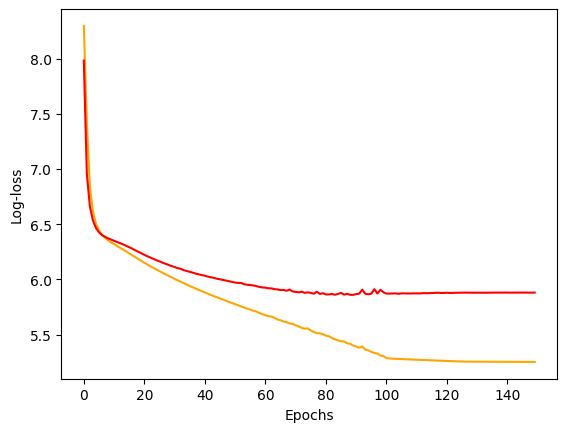

In [9]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

In [10]:
predict(GRU_Model_cuda, 'it was', 20, TimeMachine_data.vocab, cuda_device)

'it was a little man i had a little man i had a little man i had a little man i had'

In [11]:
predict(GRU_Model_cuda, 'i am', 20, TimeMachine_data.vocab, cuda_device)

'i am not a little man i had a little man i had a little man i had a little man i'

In [12]:
predict(GRU_Model_cuda, 'it is not a sword', 20, TimeMachine_data.vocab, cuda_device)

'it is not a sword i was not a little man i had a little man i had a little man i had a little'

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> CHO, Kyunghyun, et al. Learning phrase representations using RNN encoder–decoder for statistical machine translation. In: Proceedings of the 2014 conference on empirical methods in natural language processing (EMNLP). 2014. p. 1724-1734.

<a id="2">[2]</a> HOCHREITER, Sepp; SCHMIDHUBER, Jürgen. Long short-term memory. Neural computation, 1997, 9.8: 1735-1780.

<a id="3">[3]</a> ZHANG, Aston, et al. *Dive into deep learning*. Cambridge University Press, 2023.